In [1]:
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt
import optuna
from adaptive_trainer import AdaptiveTrainer
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

DATASET_SIZE = len(X_train)
ROUNDS = 15
ALPHA = 2e-5 
MAX_EPOCHS_LIMIT = 200

In [3]:
def train_eval(batch, epochs, seed=42):
    actual_batch = max(16, min(int(batch), DATASET_SIZE))
    requested_epochs = max(1, int(epochs))
    
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=min(requested_epochs, MAX_EPOCHS_LIMIT),
        batch_size=actual_batch,
        random_state=seed,
        learning_rate_init=0.001
    )

    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    
    # Calculate actual cost based on iterations performed
    cost = actual_batch * model.n_iter_
    reward = acc - (ALPHA * cost)
    return acc, cost, reward

In [4]:
def run_standard():
    return [train_eval(32, 100, seed=r) for r in range(ROUNDS)]

def run_random():
    results = []
    for r in range(ROUNDS):
        b = random.choice([16, 32, 64, 128])
        e = random.randint(50, 200)
        results.append(train_eval(b, e, seed=r))
    return results

def run_grid_search():
    # Grid search usually samples a fixed space and picks the best
    grid = ParameterGrid({'batch': [32, 64, 128], 'epochs': [50, 100, 200]})
    results = []
    # We run the grid then take the average over rounds for a fair comparison
    for r in range(ROUNDS):
        best_in_round = (0, 0, -np.inf)
        for params in grid:
            res = train_eval(params['batch'], params['epochs'], seed=r)
            if res[2] > best_in_round[2]: # Optimize for reward
                best_in_round = res
        results.append(best_in_round)
    return results

def run_optuna():
    results = []
    for r in range(ROUNDS):
        def objective(trial):
            b = trial.suggest_int("batch", 16, 128)
            e = trial.suggest_int("epochs", 50, 200)
            acc, cost, reward = train_eval(b, e, seed=r)
            trial.set_user_attr("cost", cost)
            trial.set_user_attr("reward", reward)
            return acc # Optuna focuses on accuracy by default

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=10) # 10 trials per round
        
        best_t = study.best_trial
        results.append((best_t.value, best_t.user_attrs["cost"], best_t.user_attrs["reward"]))
    return results

def run_adaptive():
    trainer = AdaptiveTrainer(alpha=ALPHA)
    results = []
    for r in range(ROUNDS):
        plan = trainer.plan({"dataset_size": DATASET_SIZE})
        acc, cost, reward = train_eval(
            batch=plan.get("pop_size", 32), 
            epochs=plan.get("max_iter", 100),
            seed=r
        )
        trainer.observe(metric=acc, cost=cost)
        results.append((acc, cost, reward))
    return results

Running comprehensive benchmark (15 rounds)...


[I 2026-01-05 00:37:43,184] A new study created in memory with name: no-name-226021f0-8452-44b0-bdf7-a1ebf5e99c99
[I 2026-01-05 00:37:43,448] Trial 0 finished with value: 0.9649122807017544 and parameters: {'batch': 86, 'epochs': 50}. Best is trial 0 with value: 0.9649122807017544.
[I 2026-01-05 00:37:43,787] Trial 1 finished with value: 0.8947368421052632 and parameters: {'batch': 115, 'epochs': 185}. Best is trial 0 with value: 0.9649122807017544.
[I 2026-01-05 00:37:44,067] Trial 2 finished with value: 0.9473684210526315 and parameters: {'batch': 97, 'epochs': 123}. Best is trial 0 with value: 0.9649122807017544.
[I 2026-01-05 00:37:44,219] Trial 3 finished with value: 0.956140350877193 and parameters: {'batch': 62, 'epochs': 186}. Best is trial 0 with value: 0.9649122807017544.
[I 2026-01-05 00:37:44,569] Trial 4 finished with value: 0.956140350877193 and parameters: {'batch': 54, 'epochs': 175}. Best is trial 0 with value: 0.9649122807017544.
[I 2026-01-05 00:37:44,725] Trial 5 fi


Strategy        | Avg Acc    | Avg Cost   | Avg Reward
---------------------------------------------------------------------------
Standard        | 0.9269     | 1363       | 0.8996
Random          | 0.9409     | 3980       | 0.8613
GridSearch      | 0.9526     | 1506       | 0.9225
Optuna(BO)      | 0.9649     | 3954       | 0.8858
Hagfish         | 0.9351     | 697        | 0.9212


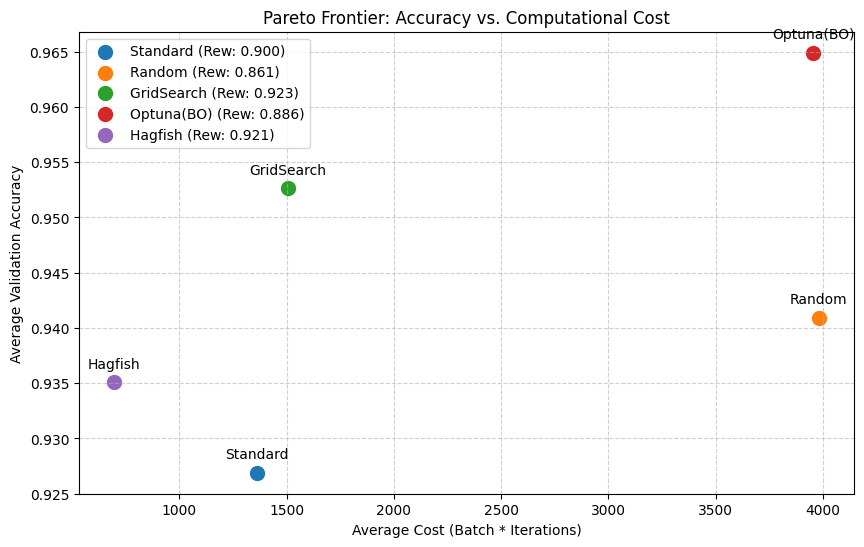

In [7]:
print(f"Running comprehensive benchmark ({ROUNDS} rounds)...")

all_results = {
    "Standard": run_standard(),
    "Random": run_random(),
    "GridSearch": run_grid_search(),
    "Optuna(BO)": run_optuna(),
    "Hagfish": run_adaptive()
}

print("\n" + "="*75)
print(f"{'Strategy':<15} | {'Avg Acc':<10} | {'Avg Cost':<10} | {'Avg Reward':<10}")
print("-" * 75)
plt.figure(figsize=(10, 6))

for name, res in all_results.items():
    avg_acc = np.mean([r[0] for r in res])
    avg_cost = np.mean([r[1] for r in res])
    avg_reward = np.mean([r[2] for r in res])

    print(f"{name:<15} | {avg_acc:.4f}     | {avg_cost:<10.0f} | {avg_reward:.4f}")
    
    # Plot for Pareto Frontier Visualization
    plt.scatter(avg_cost, avg_acc, s=100, label=f"{name} (Rew: {avg_reward:.3f})")
    plt.annotate(name, (avg_cost, avg_acc), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Pareto Frontier: Accuracy vs. Computational Cost")
plt.xlabel("Average Cost (Batch * Iterations)")
plt.ylabel("Average Validation Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()
print("="*75)